In [1]:
!pip install -q --upgrade \
  numpy==1.26.4 pandas==2.2.2 scikit-learn==1.4.2 \
  imbalanced-learn==0.12.2 transformers==4.42.1 \
  torch==2.2.2 tqdm==4.66.4 tabulate==0.9.0


In [2]:
# Core
import os
import time
import warnings

# Data
import numpy as np
import pandas as pd

# Scikit-learn (latest stable API)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    f1_score,
    classification_report,
    precision_score,
    recall_score
)

# PyTorch
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW  # recommended optimizer from torch

# Transformers (latest Hugging Face)
from transformers import RobertaTokenizer, RobertaForSequenceClassification

# Mixed precision training
from torch.cuda.amp import GradScaler, autocast

# Oversampling (Imbalanced-learn)
from imblearn.over_sampling import RandomOverSampler

# Utils
from tabulate import tabulate
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    f1_score, precision_recall_fscore_support, classification_report, ConfusionMatrixDisplay
)
from tabulate import tabulate


# Device setup
warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [3]:
config = {
    "k_folds": 5,  # 1 for no fold, 2 for two-fold, 10 for full k-fold
    "epochs": 15,
    "batch_size": 32,
    "max_length": 256,
    "learning_rate": 1e-5,
    "gradient_accumulation_steps": 2,
    "model_name": "roberta-large",
    "num_labels": 2,
    "use_amp": True,
    "random_state": 42,
    "balance_data": True,
    "early_stopping_patience": 3
}

tokenizer = RobertaTokenizer.from_pretrained(config["model_name"])


In [4]:


class RequirementsDataset(Dataset):
    def __init__(self, texts, labels):
        enc = tokenizer(texts, truncation=True, padding=True, max_length=config["max_length"], return_tensors="pt")
        self.input_ids = enc['input_ids']
        self.attention_mask = enc['attention_mask']
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": self.labels[idx]
        }

    def __len__(self):
        return len(self.labels)

In [5]:
def balance_dataset(texts, labels):
    ros = RandomOverSampler(random_state=config["random_state"])
    df = pd.DataFrame({'text': texts, 'label': labels})
    balanced_data, balanced_labels = ros.fit_resample(df[['text']], df['label'])
    return balanced_data['text'].tolist(), balanced_labels.tolist()


In [6]:
def train_and_evaluate(train_texts, train_labels, val_texts, val_labels, fold_num):
    if config["balance_data"]:
        train_texts, train_labels = balance_dataset(train_texts, train_labels)

    train_ds = RequirementsDataset(train_texts, train_labels)
    val_ds = RequirementsDataset(val_texts, val_labels)
    train_loader = DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=config["batch_size"])

    model = RobertaForSequenceClassification.from_pretrained(
        config["model_name"], 
        num_labels=config["num_labels"]
    ).to(device)

    optimizer = AdamW(model.parameters(), lr=config["learning_rate"])
    scaler = GradScaler()

    best_f1 = 0
    stop_count = 0
    all_logs = []

    for epoch in range(config["epochs"]):
        # ========== Training ==========
        model.train()
        total_train_loss = 0
        step = 0

        for batch in tqdm(train_loader, desc=f"Fold {fold_num} Epoch {epoch+1}"):
            batch = {k: v.to(device) for k, v in batch.items()}
            with autocast(config["use_amp"]):
                output = model(**batch)
                loss = output.loss / config["gradient_accumulation_steps"]

            scaler.scale(loss).backward()
            step += 1

            if step % config["gradient_accumulation_steps"] == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            total_train_loss += loss.item() * config["gradient_accumulation_steps"]

        avg_train_loss = total_train_loss / len(train_loader)

        # ========== Validation ==========
        model.eval()
        preds, targets = [], []
        total_val_loss = 0

        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.to(device) for k, v in batch.items()}
                with autocast(config["use_amp"]):
                    output = model(**batch)

                loss = output.loss
                total_val_loss += loss.item()

                logits = output.logits
                preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                targets.extend(batch["labels"].cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        f1 = f1_score(targets, preds, average="macro")

        # Save logs
        all_logs.append((epoch+1, avg_train_loss, avg_val_loss, f1))

        # Print after each epoch
        print(f"📊 Fold {fold_num} | Epoch {epoch+1} | "
              f"Train Loss={avg_train_loss:.4f} | Val Loss={avg_val_loss:.4f} | F1={f1:.4f}")

        # Early stopping
        if f1 > best_f1:
            best_f1 = f1
            stop_count = 0
        else:
            stop_count += 1
            if stop_count >= config["early_stopping_patience"]:
                print("⏹️ Early stopping triggered.")
                break

    # Pretty summary
    print("\n🔎 Per-Epoch Summary:")
    print(tabulate([(e, round(tr, 4), round(vl, 4), round(f, 4)) 
                    for e, tr, vl, f in all_logs],
                   headers=["Epoch", "Train Loss", "Val Loss", "F1"]))

    print("\n📑 Final classification report:")
    print(classification_report(targets, preds, target_names=["NFR", "F"]))

    return preds, targets, f1


In [7]:
df = pd.read_csv("/kaggle/input/promise-original/promise_nfr_original.csv", sep=";")
print(f"✅ Loaded {len(df)} samples")

# F = 1 (Functional), others = 0 (NFR)
df["label"] = df["class"].apply(lambda x: 1 if x == "F" else 0)
df.dropna(subset=["RequirementText", "label"], inplace=True)

print(f"✅ After filtering: {len(df)} rows")
print("📊 Class distribution:\n", df["label"].value_counts())
print("🧠 Unique original class types:\n", df["class"].value_counts())

# ========== Train & Evaluate ==========
all_scores = []
all_preds_global = []
all_targets_global = []

if config["k_folds"] == 1:
    print("\n🚀 Using holdout split (80/20)")
    train_texts, val_texts, train_labels, val_labels = train_test_split(
        df["RequirementText"].tolist(),
        df["label"].tolist(),
        test_size=0.2,
        stratify=df["label"],
        random_state=config["random_state"]
    )
    print(f"🧾 Train size: {len(train_texts)} | Val size: {len(val_texts)}")

    preds, targets, score = train_and_evaluate(train_texts, train_labels, val_texts, val_labels, fold=1)
    all_preds_global.extend(preds)
    all_targets_global.extend(targets)
    all_scores.append(score)

else:
    print(f"\n🔁 Running {config['k_folds']}-Fold Stratified CV")
    skf = StratifiedKFold(n_splits=config["k_folds"], shuffle=True, random_state=config["random_state"])

    for fold, (train_idx, val_idx) in enumerate(skf.split(df["RequirementText"], df["label"])):
        train_texts = df.iloc[train_idx]["RequirementText"].tolist()
        train_labels = df.iloc[train_idx]["label"].tolist()
        val_texts = df.iloc[val_idx]["RequirementText"].tolist()
        val_labels = df.iloc[val_idx]["label"].tolist()

        print(f"\n📂 Fold {fold + 1}: Train={len(train_texts)}, Val={len(val_texts)}")

        preds, targets, score = train_and_evaluate(train_texts, train_labels, val_texts, val_labels, fold+1)
        all_preds_global.extend(preds)
        all_targets_global.extend(targets)
        all_scores.append(score)

# ========== Print Scores ==========
print("\n📈 All Macro F1 Scores:", all_scores)
print(f"📊 Avg F1 = {np.mean(all_scores):.4f} ± {np.std(all_scores):.4f}")

✅ Loaded 625 samples
✅ After filtering: 625 rows
📊 Class distribution:
 label
0    370
1    255
Name: count, dtype: int64
🧠 Unique original class types:
 class
F     255
US     67
SE     66
O      62
PE     54
LF     38
A      21
SC     21
MN     17
L      13
FT     10
PO      1
Name: count, dtype: int64

🔁 Running 5-Fold Stratified CV

📂 Fold 1: Train=500, Val=125


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Fold 1 Epoch 1:   0%|          | 0/19 [00:00<?, ?it/s]

📊 Fold 1 | Epoch 1 | Train Loss=0.7013 | Val Loss=0.6721 | F1=0.3719


Fold 1 Epoch 2:   0%|          | 0/19 [00:00<?, ?it/s]

...

📊 Fold 5 | Epoch 10 | Train Loss=0.0268 | Val Loss=0.2772 | F1=0.9236


Fold 5 Epoch 11:   0%|          | 0/19 [00:00<?, ?it/s]

📊 Fold 5 | Epoch 11 | Train Loss=0.0274 | Val Loss=0.4843 | F1=0.8877


Fold 5 Epoch 12:   0%|          | 0/19 [00:00<?, ?it/s]

📊 Fold 5 | Epoch 12 | Train Loss=0.0203 | Val Loss=0.4588 | F1=0.8772
⏹️ Early stopping triggered.

🔎 Per-Epoch Summary:
  Epoch    Train Loss    Val Loss      F1
-------  ------------  ----------  ------
      1        0.6799      0.5966  0.5438
      2        0.5497      0.395   0.8276
      3        0.3506      0.2576  0.9086
      4        0.1828      0.2133  0.9177
      5        0.1052      0.2844  0.9236
      6        0.0776      0.417   0.8866
      7        0.0507      0.4121  0.8785
      8        0.0451      0.2473  0.9247
      9        0.0343      0.2272  0.9333
     10        0.0268      0.2772  0.9236
     11        0.0274      0.4843  0.8877
     12        0.0203      0.4588  0.8772

📑 Final classification report:
              precision    recall  f1-score   support

         NFR       0.84      1.00      0.91        74
           F       1.00      0.73      0.84        51

    accuracy                           0.89       125
   macro avg       0.92      0.86      0.

In [8]:
precision, recall, f1, support = precision_recall_fscore_support(
    all_targets_global, all_preds_global, labels=[0, 1], zero_division=0
)

labels = ["NFR (0)", "F (1)"]
class_scores = []

for i, label in enumerate(labels):
    class_scores.append({
        "Class": label,
        "Precision": round(precision[i], 4),
        "Recall": round(recall[i], 4),
        "F1 Score": round(f1[i], 4),
        "Support": support[i]
    })

print("\n📋 F1 Score Table for NFR (0):")
print(tabulate([class_scores[0]], headers="keys", tablefmt="fancy_grid"))

print("\n📋 F1 Score Table for F (1):")
print(tabulate([class_scores[1]], headers="keys", tablefmt="fancy_grid"))



📋 F1 Score Table for NFR (0):
╒═════════╤═════════════╤══════════╤════════════╤═══════════╕
│ Class   │   Precision │   Recall │   F1 Score │   Support │
╞═════════╪═════════════╪══════════╪════════════╪═══════════╡
│ NFR (0) │      0.8834 │   0.9622 │     0.9211 │       370 │
╘═════════╧═════════════╧══════════╧════════════╧═══════════╛

📋 F1 Score Table for F (1):
╒═════════╤═════════════╤══════════╤════════════╤═══════════╕
│ Class   │   Precision │   Recall │   F1 Score │   Support │
╞═════════╪═════════════╪══════════╪════════════╪═══════════╡
│ F (1)   │      0.9369 │   0.8157 │     0.8721 │       255 │
╘═════════╧═════════════╧══════════╧════════════╧═══════════╛


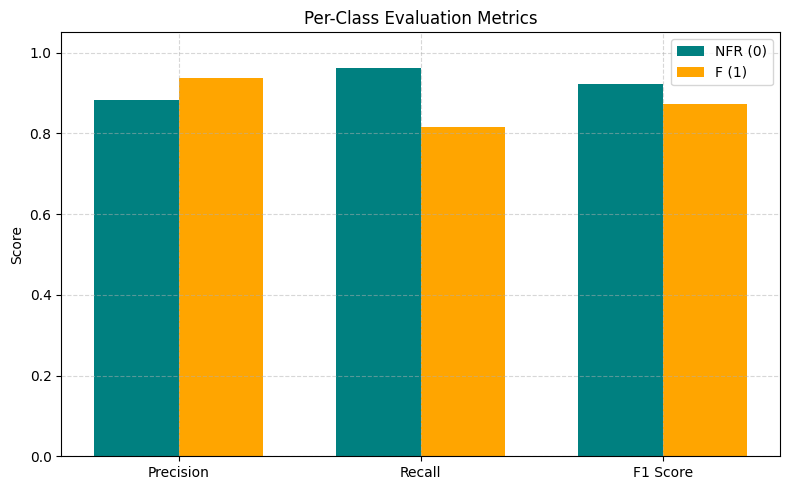

In [9]:
metrics = ["Precision", "Recall", "F1 Score"]
nfr_vals = [precision[0], recall[0], f1[0]]
f_vals = [precision[1], recall[1], f1[1]]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, nfr_vals, width, label="NFR (0)", color="teal")
ax.bar(x + width/2, f_vals, width, label="F (1)", color="orange")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Per-Class Evaluation Metrics")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


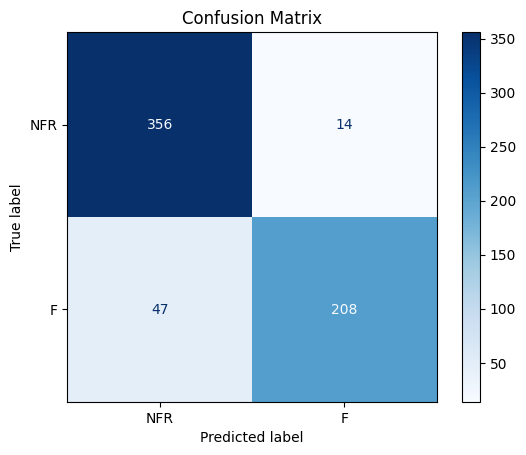

In [10]:
ConfusionMatrixDisplay.from_predictions(
    all_targets_global,
    all_preds_global,
    display_labels=["NFR", "F"],
    cmap="Blues",
    values_format="d"
)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()


In [11]:
# ==============================
# 🔍 SHAP Explainability on Final RoBERTa Model
# ==============================
import shap

print("\n🟢 Running SHAP explainability...")

# Train final model on all data (for SHAP)
final_texts = df["RequirementText"].tolist()
final_labels = df["label"].tolist()

full_dataset = RequirementsDataset(final_texts, final_labels)
full_loader = DataLoader(full_dataset, batch_size=config["batch_size"], shuffle=True)

final_model = RobertaForSequenceClassification.from_pretrained(
    config["model_name"], num_labels=config["num_labels"]
).to(device)

optimizer = AdamW(final_model.parameters(), lr=config["learning_rate"])
scaler = GradScaler()

# Simple training loop (few epochs, optional)
final_model.train()
for epoch in range(2):  # keep it small for SHAP
    total_loss = 0
    for batch in tqdm(full_loader, desc=f"Final Training Epoch {epoch+1}"):
        batch = {k: v.to(device) for k, v in batch.items()}
        with autocast(config["use_amp"]):
            output = final_model(**batch)
            loss = output.loss
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} | Loss: {total_loss/len(full_loader):.4f}")

final_model.eval()

# Prediction wrapper for SHAP
def predict(texts):
    enc = tokenizer(list(texts), truncation=True, padding=True,
                    max_length=config["max_length"], return_tensors="pt")
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        outputs = final_model(**enc)
        probs = torch.softmax(outputs.logits, dim=1)
        return probs.cpu().numpy()

# SHAP explainer setup
background = df["RequirementText"].sample(20, random_state=42).tolist()
masker = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(predict, masker, algorithm="partition")

# Pick test samples
sample_df = df.sample(10, random_state=0)
test_samples = sample_df["RequirementText"].tolist()
true_labels = sample_df["label"].tolist()

# Run SHAP
shap_values = explainer(test_samples)

# Build explanations table
rows = []
preds = np.argmax(predict(test_samples), axis=1)

for i, text in enumerate(test_samples):
    token_scores = list(zip(shap_values.data[i], shap_values.values[i][:,1]))  # scores for class 1 (Functional)
    token_scores_sorted = sorted(token_scores, key=lambda x: abs(x[1]), reverse=True)

    positive_tokens = [tok for tok, score in token_scores_sorted if score > 0][:5]
    negative_tokens = [tok for tok, score in token_scores_sorted if score < 0][:5]

    if preds[i] == 1:
        rationale = f"Predicted **Functional** due to terms like {', '.join(positive_tokens)}."
        if negative_tokens:
            rationale += f" Words like {', '.join(negative_tokens)} reduced confidence."
    else:
        rationale = f"Predicted **Non-Functional** due to terms like {', '.join(positive_tokens)}."
        if negative_tokens:
            rationale += f" Down-weighted terms: {', '.join(negative_tokens)}."

    rows.append({
        "Requirement": text,
        "Actual": "Functional" if true_labels[i] == 1 else "Non-Functional",
        "Predicted": "Functional" if preds[i] == 1 else "Non-Functional",
        "Explanation": rationale
    })

shap_table = pd.DataFrame(rows)
display(shap_table)
shap_table.to_csv("shap_roberta_explanations.csv", index=False)



🟢 Running SHAP explainability...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Final Training Epoch 1:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1 | Loss: 0.6995


Final Training Epoch 2:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 2 | Loss: 0.6647


2025-09-07 09:50:20.695552: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757238620.713351     588 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757238620.718485     588 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 11it [00:33,  3.70s/it]                        


,Requirement,Actual,Predicted,Explanation
0,The System shall meet all applicable accountin...,Non-Functional,Non-Functional,Predicted **Non-Functional** due to terms like...
1,The product must be able to interface with any...,Non-Functional,Non-Functional,Predicted **Non-Functional** due to terms like...
2,Only registered customers can purchase streami...,Non-Functional,Non-Functional,Predicted **Non-Functional** due to terms like...
3,The product shall be able to be installed in a...,Non-Functional,Non-Functional,Predicted **Non-Functional** due to terms like...
4,Only authorized personnel can access sales inf...,Non-Functional,Non-Functional,Predicted **Non-Functional** due to terms like...
5,90% of untrained realtors shall be able to ins...,Non-Functional,Functional,Predicted **Functional** due to terms like Ġw...
6,The product shall free of computer viruses.,Non-Functional,Non-Functional,Predicted **Non-Functional** due to terms like...
7,Website shall allow customers to purchase pre...,Functional,Non-Functional,Predicted **Non-Functional** due to terms like...
8,On a 112k connection or faster the system re...,Non-Functional,Non-Functional,Predicted **Non-Functional** due to terms like...
9,Users shall feel satisfied using the product. ...,Non-Functional,Non-Functional,Predicted **Non-Functional** due to terms like...
